# **📩 Spam Metin Sınıflandırma (NLP Uygulaması)**

Bu çalışmada, RNN tabanlı modeller kullanarak bir spam mesaj sınıflandırıcı geliştireceksiniz.

Veri seti:

1. sütun → Etiket (spam / ham)
2. sütun → Mesaj metni

**🧪 Kullanılacak Yöntemler**

Bu çalışmada aşağıdaki teknikleri uygulayacaksınız:

Embedding (Gömme katmanı)
SimpleRNN
GRU
LSTM
Ensemble Model (Model birleştirme)

**⚙️ Veri Ön İşleme**

Model eğitimi öncesinde metin verisi üzerinde şu işlemleri uygulayacaksınız:

**Tokenization →** Metinleri sayısal ifadelere dönüştürme

**Padding →** Tüm dizileri aynı uzunluğa getirme

📌 Bu adımlar, metin verisinin sinir ağına girdi olarak verilebilmesi için zorunludur.

**📌 Not:**

Detaylı katman açıklamaları için aşağıdaki dokümantasyonları inceleyebilirsiniz:

SimpleRNN: https://keras.io/api/layers/recurrent_layers/simple_rnn/

LSTM: https://keras.io/api/layers/recurrent_layers/lstm/




# **Gerekli Kütüphaneler**

Bu bölümde, metin sınıflandırma problemi için kullanılacak temel kütüphaneleri içe aktarmanız beklenmektedir.

*   RNN tabanlı modeller için SimpleRNN, LSTM ve Embedding katmanlarına ihtiyacınız olacak
*   Veri işlemleri için pandas ve numpy kullanabilirsiniz
*   Görselleştirme için matplotlib ve seaborn tercih edilebilir





In [230]:
import pandas as pd
import numpy as np

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, SimpleRNN, Dense

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# **Veri Setinin Yüklenmesi**

Bu adımda, spam mesaj sınıflandırma problemi için kullanılacak veri setini içe aktarmanız beklenmektedir.

👉 Görev:

`"datasets_2050_3494_SPAM text message 20170820 - Data"` isimli veri setini uygun bir yöntemle yükleyin

Veri setini bir DataFrame olarak saklayın

İlk birkaç satırı görüntüleyerek veri yapısını inceleyin

In [231]:
import os
os.listdir("/content")

['.config',
 'datasets_2050_3494_SPAM text message 20170820 - Data (1).csv',
 'datasets_2050_3494_SPAM text message 20170820 - Data.csv',
 'sample_data']

In [232]:
import pandas as pd

df = pd.read_csv("/content/datasets_2050_3494_SPAM text message 20170820 - Data.csv")

df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [233]:
df.columns

Index(['Category', 'Message'], dtype='object')

In [234]:
df.columns = ["label", "text"]

# **Veri Keşfi (Exploratory Analysis)**

*   Veri setinin ilk 20 satırını görüntüleyin
*   Veri setinde spam ve non-spam (ham) mesajların sayısını hesaplayın
*   Her iki sınıfın veri setindeki dağılımını gözlemleyin
*   Mesaj metinlerini bir liste/array yapısında toplayın
*   Etiketleri sayısal forma dönüştürün
*   ham → 0, spam → 1 olacak şekilde kodlayın
*   Metinler ve etiketlerin boyutlarını kontrol edin



In [235]:
import os

os.listdir("/content")

['.config',
 'datasets_2050_3494_SPAM text message 20170820 - Data (1).csv',
 'datasets_2050_3494_SPAM text message 20170820 - Data.csv',
 'sample_data']

In [236]:
import os
os.listdir("/content")

['.config',
 'datasets_2050_3494_SPAM text message 20170820 - Data (1).csv',
 'datasets_2050_3494_SPAM text message 20170820 - Data.csv',
 'sample_data']

In [237]:
import pandas as pd

df = pd.read_csv("datasets_2050_3494_SPAM text message 20170820 - Data.csv")

df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [238]:
df.columns

Index(['Category', 'Message'], dtype='object')

In [239]:
df.columns = ["label", "text"]

In [240]:
df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


# **Metinlerin Sayısallaştırılması ve Sabit Uzunluğa Getirilmesi**

Bu aşamada metin verisini modele uygun hale getirmek için gerekli ön işleme adımlarını uygulamanız beklenmektedir.

**👉 Görev:**

Metinleri sayısal dizilere dönüştürmek için gerekli araçları içe aktarın

Sözlükte kullanılacak maksimum kelime sayısını belirleyin

Her mesaj için kullanılacak maksimum dizi uzunluğunu tanımlayın

**📌 İpucu:**

Tokenizer metinleri tamsayı dizilerine dönüştürmek için kullanılır

pad_sequences tüm dizileri aynı uzunluğa getirmek için kullanılır

Çok sık geçen kelimelere odaklanmak için kelime dağarcığını belirli bir üst sınırla kısıtlayabilirsiniz

In [241]:
from tensorflow.keras.preprocessing.text import Tokenizer

# DataFrame'den metin ve etiketleri al
texts = df["text"].values
labels = df["label"].values

# tokenizer
max_words = 5000
tokenizer = Tokenizer(num_words=max_words)

tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)

In [242]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = 100  # maksimum mesaj uzunluğu

X = pad_sequences(sequences, maxlen=max_len)

In [243]:
y = labels

In [244]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5572, 100)
y shape: (5572,)


# **Eğitim ve Test Verisinin Ayrılması**

Modeli eğitmek ve değerlendirmek için veri setini iki parçaya ayırmanız gerekmektedir.

**👉 Görev:**

Veri setinin yaklaşık %80’ini eğitim, kalanını test (validation) verisi olarak ayırın

Eğitim ve test veri sayılarının toplamının, veri setinin tamamına eşit olduğunu kontrol edin


📌 Not:
Gerçek uygulamalarda train / validation / test şeklinde üçlü ayrım tercih edilir, ancak bu çalışmada ikiye bölme yeterlidir.

In [245]:
from sklearn.model_selection import train_test_split

# %80 eğitim - %20 test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [246]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4457, 100)
X_test: (1115, 100)
y_train: (4457,)
y_test: (1115,)


# **Tokenization ve Padding Uygulaması**

Bu aşamada metin verisini modele girdi olarak verebilmek için gerekli dönüşümleri gerçekleştirmeniz beklenmektedir.

**👉 Görev:**

Metinleri kullanarak bir tokenizer oluşturun ve eğitin

Metinleri tamsayı dizilerine (sequences) dönüştürün

Veri setindeki benzersiz kelime sayısını inceleyin

Elde edilen dizileri sabit uzunluğa (maxlen) getirin

**📌 Dikkat:**

Padding işlemini varsayılan (pre-padding) ya da post olacak şekilde deneyebilirsiniz

Sonuçta oluşan veri boyutunun (örnek sayısı, maxlen) şeklinde olması gerekir

# **Verinin Karıştırılması ve Bölünmesi**

Modelin daha sağlıklı öğrenebilmesi için verinin rastgele karıştırılması gerekmektedir.

**👉 Görev:**

Veri ve etiketleri aynı sırayı koruyacak şekilde karıştırın (shuffle)

Karıştırılmış veriyi daha önce belirlediğiniz oranlara göre eğitim ve test olarak ayırın

In [247]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


texts = df["text"].values


max_words = 5000
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(texts)


sequences = tokenizer.texts_to_sequences(texts)


print("Benzersiz kelime sayısı:", len(tokenizer.word_index))


max_len = 100
X = pad_sequences(sequences, maxlen=max_len)


y = df["label"].map({'ham': 0, 'spam': 1}).values # Etiketleri sayısal hale getir

print("X shape:", X.shape)
print("y shape:", y.shape)

Benzersiz kelime sayısı: 9004
X shape: (5572, 100)
y shape: (5572,)


In [248]:
from sklearn.utils import shuffle

# veriyi karıştır
X, y = shuffle(X, y, random_state=42)

In [249]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# **Model Oluşturma (SimpleRNN)**
Bu aşamada, metin sınıflandırma problemi için bir RNN tabanlı model oluşturmanız beklenmektedir.

**👉 Görev:**

Sıralı bir model (Sequential) oluşturun

İlk katman olarak Embedding katmanı ekleyin

Ardından bir SimpleRNN katmanı kullanın

Çıkış için Dense + sigmoid aktivasyonlu bir katman ekleyin

**👉 Devamında:**

Modeli uygun loss ve optimizer ile derleyin

Eğitim verisi ile modeli eğitin

Eğitim sürecini (epoch, batch_size, validation) ayarlayın

 **📌 Not:Aynı mimariyi daha sonra GRU ve LSTM katmanları ile de kurarak performans karşılaştırması yapacaksınız.**

In [250]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense


model_rnn = Sequential()


model_rnn.add(Embedding(input_dim=5000, output_dim=64, input_length=100))


model_rnn.add(SimpleRNN(64))


model_rnn.add(Dense(1, activation="sigmoid"))


model_rnn.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)


history_rnn = model_rnn.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.8573 - loss: 0.4012 - val_accuracy: 0.8547 - val_loss: 0.3857
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.9033 - loss: 0.2493 - val_accuracy: 0.9830 - val_loss: 0.0738
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.9881 - loss: 0.0428 - val_accuracy: 0.9794 - val_loss: 0.0701
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9951 - loss: 0.0210 - val_accuracy: 0.9848 - val_loss: 0.0504
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9969 - loss: 0.0120 - val_accuracy: 0.9848 - val_loss: 0.0559


# **Model Performansının Görselleştirilmesi**

Model eğitildikten sonra performansını analiz etmek için eğitim sürecindeki metrikleri görselleştirmeniz gerekmektedir.

**👉 Görev:**

Eğitim sırasında elde edilen accuracy ve loss değerlerini alın

Hem training hem validation için:

Accuracy grafiği çizdirin

Loss grafiği çizdirin


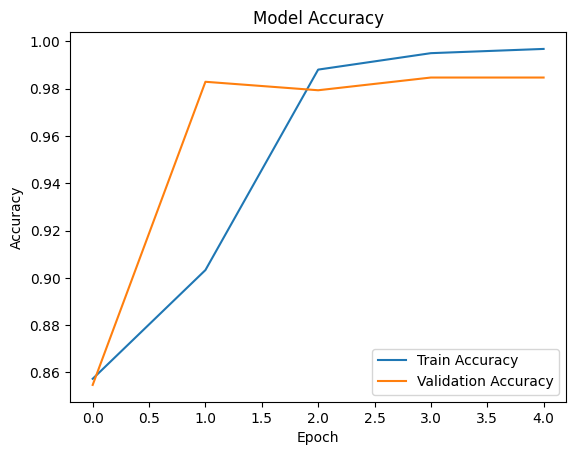

In [251]:
import matplotlib.pyplot as plt


plt.plot(history_rnn.history["accuracy"], label="Train Accuracy")
plt.plot(history_rnn.history["val_accuracy"], label="Validation Accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

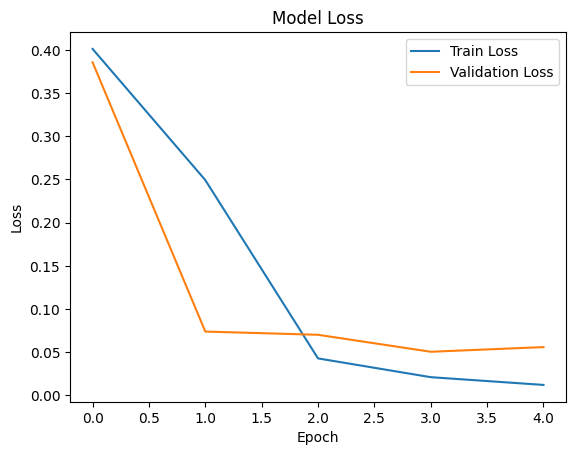

In [252]:

plt.plot(history_rnn.history["loss"], label="Train Loss")
plt.plot(history_rnn.history["val_loss"], label="Validation Loss")

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# **Modelin Test Edilmesi ve Değerlendirilmesi**

Eğitilen modelin test verisi üzerindeki performansını değerlendirmeniz beklenmektedir.

**👉 Görev:**

Test verisi üzerinde modelin tahminlerini elde edin

Modelin loss ve accuracy değerlerini hesaplayın

Tahmin sonuçlarını analiz etmek için confusion matrix oluşturun

In [253]:
loss, accuracy = model_rnn.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9848 - loss: 0.0559
Test Loss: 0.05586579814553261
Test Accuracy: 0.9847533702850342


In [254]:
y_pred = model_rnn.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


In [255]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[953   0]
 [ 17 145]]


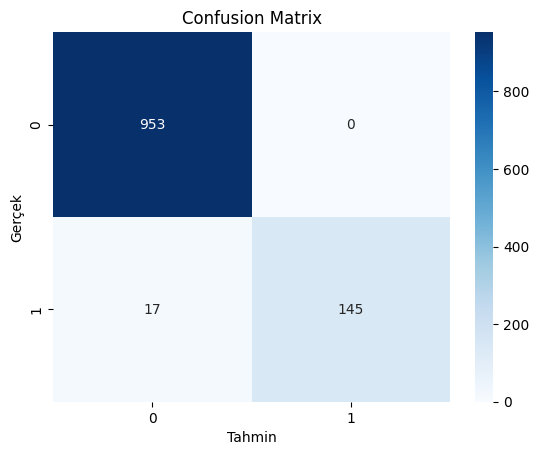

In [256]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.title("Confusion Matrix")
plt.show()

# **Model Oluşturma (GRU)**

Bu aşamada, önceki modele benzer yapıda bir GRU tabanlı metin sınıflandırma modeli geliştirmeniz beklenmektedir.

**👉 Görev:**

Sequential yapısını kullanarak yeni bir model oluşturun

İlk katmanda Embedding kullanın

Ardından GRU katmanı ekleyin

Çıkış katmanında Dense + sigmoid yapısını kullanın

**👉 Devamında:**

Modeli ikili sınıflandırmaya uygun şekilde derleyin

Eğitim verisi ile modeli eğitin

Eğitim sürecindeki performansı daha sonra SimpleRNN modeli ile karşılaştırı

In [257]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense


model_gru = Sequential()

model_gru.add(Embedding(input_dim=5000, output_dim=64, input_length=100))


model_gru.add(GRU(64))


model_gru.add(Dense(1, activation="sigmoid"))


model_gru.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)


history_gru = model_gru.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


140/140 ━━━━━━━━━━━━━━━━━━━━ 13s 74ms/step - accuracy: 0.9329 - loss: 0.1908 - val_accuracy: 0.9821 - val_loss: 0.0626
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step - accuracy: 0.9904 - loss: 0.0353 - val_accuracy: 0.9857 - val_loss: 0.0489
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.9955 - loss: 0.0183 - val_accuracy: 0.9874 - val_loss: 0.0549
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - accuracy: 0.9980 - loss: 0.0079 - val_accuracy: 0.9883 - val_loss: 0.0587
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 75ms/step - accuracy: 0.9984 - loss: 0.0049 - val_accuracy: 0.9857 - val_loss: 0.0576


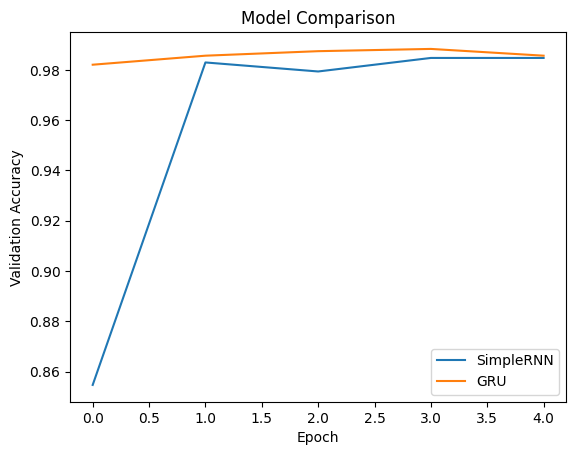

In [258]:
import matplotlib.pyplot as plt

plt.plot(history_rnn.history["val_accuracy"], label="SimpleRNN")
plt.plot(history_gru.history["val_accuracy"], label="GRU")

plt.title("Model Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

In [259]:
print("SimpleRNN Loss:", history_rnn.history["val_loss"][-1])
print("GRU Loss:", history_gru.history["val_loss"][-1])

SimpleRNN Loss: 0.05586579814553261
GRU Loss: 0.05758640915155411


# **GRU Modelinin Değerlendirilmesi**

Eğitilen GRU modelinin test verisi üzerindeki performansını analiz ediniz.

**👉 Görev:**

Test verisi için model tahminlerini elde edin

Modelin loss ve accuracy değerlerini hesaplayın

Sonuçları değerlendirmek için confusion matrix oluşturun

In [260]:
loss_gru, acc_gru = model_gru.evaluate(X_test, y_test)

print("GRU Test Loss:", loss_gru)
print("GRU Test Accuracy:", acc_gru)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9857 - loss: 0.0576
GRU Test Loss: 0.05758640915155411
GRU Test Accuracy: 0.9856502413749695


In [261]:
y_pred_gru = model_gru.predict(X_test)
y_pred_gru = (y_pred_gru > 0.5).astype(int)

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


In [262]:
from sklearn.metrics import confusion_matrix

cm_gru = confusion_matrix(y_test, y_pred_gru)
print(cm_gru)

[[949   4]
 [ 12 150]]


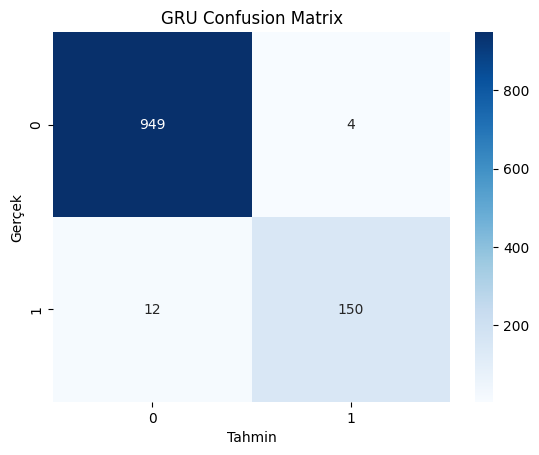

In [263]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm_gru, annot=True, fmt="d", cmap="Blues")
plt.title("GRU Confusion Matrix")
plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.show()

# **Model Oluşturma (LSTM)**

Bu aşamada, aynı mimariyi kullanarak bir LSTM tabanlı model geliştirmeniz beklenmektedir.

**👉 Görev:**

Sequential model yapısını kullanarak yeni bir model oluşturun

İlk katman olarak Embedding ekleyin

Tekrarlayan katman olarak LSTM kullanın

Çıkış katmanında Dense + sigmoid yapısını tanımlayın

**👉 Devamında:**

Modeli uygun loss ve optimizer ile derleyin

Eğitim verisi ile modeli eğitin

In [223]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense


model_lstm = Sequential()


model_lstm.add(Embedding(input_dim=5000, output_dim=64, input_length=100))


model_lstm.add(LSTM(64))


model_lstm.add(Dense(1, activation="sigmoid"))


model_lstm.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)


history_lstm = model_lstm.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


140/140 ━━━━━━━━━━━━━━━━━━━━ 12s 63ms/step - accuracy: 0.9376 - loss: 0.1904 - val_accuracy: 0.9830 - val_loss: 0.0638
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - accuracy: 0.9888 - loss: 0.0436 - val_accuracy: 0.9857 - val_loss: 0.0534
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.9948 - loss: 0.0215 - val_accuracy: 0.9830 - val_loss: 0.0553
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - accuracy: 0.9971 - loss: 0.0118 - val_accuracy: 0.9857 - val_loss: 0.0565
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - accuracy: 0.9975 - loss: 0.0074 - val_accuracy: 0.9865 - val_loss: 0.0512


# **LSTM Model Performansının Görselleştirilmesi**

LSTM modelinin eğitim sürecini analiz etmek için performans metriklerini görselleştiriniz.

**👉 Görev:**

Eğitim sürecinde elde edilen accuracy ve loss değerlerini alın

**Hem training hem validation için:**

Accuracy grafiği oluşturun

Loss grafiği oluşturun

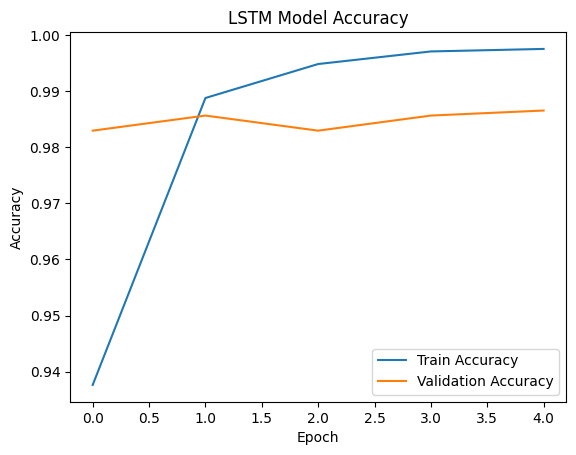

In [224]:
import matplotlib.pyplot as plt

plt.plot(history_lstm.history["accuracy"], label="Train Accuracy")
plt.plot(history_lstm.history["val_accuracy"], label="Validation Accuracy")

plt.title("LSTM Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

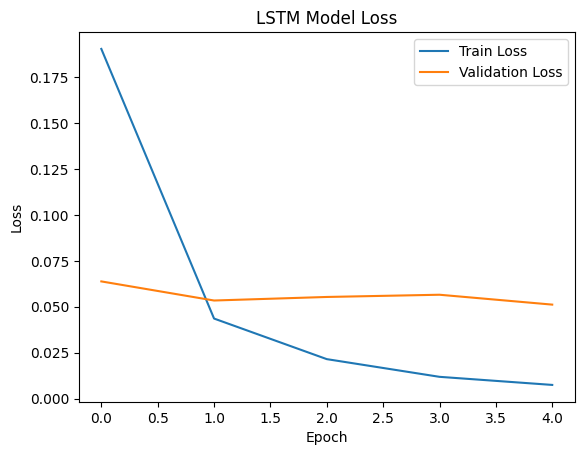

In [225]:
plt.plot(history_lstm.history["loss"], label="Train Loss")
plt.plot(history_lstm.history["val_loss"], label="Validation Loss")

plt.title("LSTM Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# **LSTM Modelinin Değerlendirilmesi**

Eğitilen LSTM modelinin test verisi üzerindeki performansını analiz ediniz.

**👉 Görev:**

Test verisi üzerinde model tahminlerini elde edin

Modelin loss ve accuracy değerlerini hesaplayın

Sonuçları incelemek için confusion matrix oluşturun

In [226]:
loss_lstm, acc_lstm = model_lstm.evaluate(X_test, y_test)

print("LSTM Test Loss:", loss_lstm)
print("LSTM Test Accuracy:", acc_lstm)

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9865 - loss: 0.0512
LSTM Test Loss: 0.05116742104291916
LSTM Test Accuracy: 0.9865471124649048


In [227]:
y_pred_lstm = model_lstm.predict(X_test)
y_pred_lstm = (y_pred_lstm > 0.5).astype(int)

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


In [228]:
from sklearn.metrics import confusion_matrix

cm_lstm = confusion_matrix(y_test, y_pred_lstm)
print(cm_lstm)

[[946   7]
 [  8 154]]


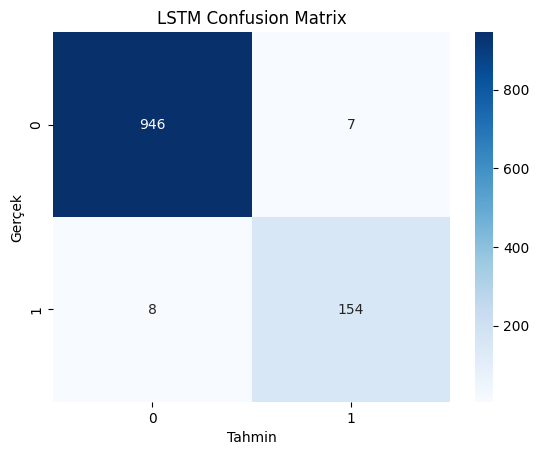

In [229]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm_lstm, annot=True, fmt="d", cmap="Blues")
plt.title("LSTM Confusion Matrix")
plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.show()